In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
zbest_path = '/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/denali/testdenali/All/alltiles_Allzinfo.fits'
zbest_columns = ['TARGETID', 'CHI2', 'Z', 'ZERR', 'ZWARN', 'SPECTYPE', 'SUBTYPE', 'DELTACHI2', 'PETAL_LOC', 'DEVICE_LOC', 'LOCATION', 'FIBER', 'FIBERSTATUS', 'TARGET_RA', 'TARGET_DEC', 'PMRA', 'PMDEC', 'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_IVAR_G', 'FLUX_IVAR_R', 'FLUX_IVAR_Z', 'GAIA_PHOT_G_MEAN_MAG', 'EBV', 'FLUX_W1', 'FLUX_W2', 'FIBERFLUX_R', 'FIBERFLUX_Z', 'FIBERTOTFLUX_Z', 'MASKBITS', 'SERSIC', 'PHOTSYS', 'SV1_DESI_TARGET', 'SV1_BGS_TARGET', 'SV1_MWS_TARGET', 'TILEID', 'COADD_NUMEXP', 'COADD_EXPTIME', 'EXPS', 'TSNR2_ELG', 'TSNR2_BGS', 'TSNR2_QSO', 'TSNR2_LRG', 'EFFTIME_DARK', 'EFFTIME_BRIGHT', 'EFFTIME_BACK', 'coadd_type', 'TARGETS', 'FIRST_EXPID', 'subset']

tmp = Table(fitsio.read(zbest_path, columns=['SV1_DESI_TARGET', 'TARGETS', 'coadd_type']))
mask = (tmp['SV1_DESI_TARGET'] & 2**0 > 0) & (tmp['TARGETS']=='QSO+LRG') & (tmp['coadd_type']!='pernight')
idx = np.where(mask)[0]

zbest = Table(fitsio.read(zbest_path, columns=zbest_columns, rows=idx))
print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

581288
52023


In [4]:
deep = zbest.copy()

# Select deep coadds
mask = deep['coadd_type']=='cumulative'
print(np.sum(mask))
# # Select QSO+LRG tiles
# mask &= deep['TARGETS']=='QSO+LRG'
# print(np.sum(mask))
deep = deep[mask]

# Remove FIBERSTATUS!=0 fibers
mask = deep['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove "no data" fibers
mask = deep['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Require a minimum depth for the deep coadd
min_depth = 3000.
mask = deep['EFFTIME_DARK']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
deep = deep[mask]

52268
FIBERSTATUS 43371 8897 0.17021887196755184
No data 43368 3 6.917064397869545e-05
Min depth 31466 11902 0.7255580151263604


In [5]:
print(len(deep))
print(len(np.unique(deep['TARGETID'])))

deep_columns_old = ['Z', 'ZERR', 'ZWARN', 'SPECTYPE', 'SUBTYPE', 'DELTACHI2', 'EFFTIME_DARK', 'EFFTIME_BRIGHT', 'EFFTIME_BACK']
deep_columns_new = ['Z_deep', 'ZERR_deep', 'ZWARN_deep', 'SPECTYPE_deep', 'SUBTYPE_deep', 'DELTACHI2_deep', 'EFFTIME_DARK_deep', 'EFFTIME_BRIGHT_deep', 'EFFTIME_BACK_deep']
deep.rename_columns(deep_columns_old, deep_columns_new)

31466
31408


In [6]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    deep['gmag'] = 22.5 - 2.5*np.log10(deep['FLUX_G']) - 3.214 * deep['EBV']
    deep['rmag'] = 22.5 - 2.5*np.log10(deep['FLUX_R']) - 2.165 * deep['EBV']
    deep['zmag'] = 22.5 - 2.5*np.log10(deep['FLUX_Z']) - 1.211 * deep['EBV']
    deep['w1mag'] = 22.5 - 2.5*np.log10(deep['FLUX_W1']) - 0.184 * deep['EBV']
    deep['w2mag'] = 22.5 - 2.5*np.log10(deep['FLUX_W2']) - 0.113 * deep['EBV']
    deep['rfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_R']) - 2.165 * deep['EBV']
    deep['zfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_Z']) - 1.211 * deep['EBV']

In [7]:
mask = zbest['coadd_type']=='perexp'
zbest = zbest[mask]
print(len(zbest))

zbest['EXPID'] = np.array(np.char.replace(zbest['subset'], 'exp', ''), dtype=int)

mask = np.in1d(zbest['TARGETID'], deep['TARGETID'])
zbest = zbest[mask]
print(len(zbest))

print(len(np.unique(zbest['TARGETID'])))

deep_columns = deep_columns_new+['TARGETID', 'gmag', 'rmag', 'zmag', 'w1mag', 'w2mag', 'rfibermag', 'zfibermag']
zbest = join(zbest, deep[deep_columns], keys='TARGETID')

529020
392093
31408


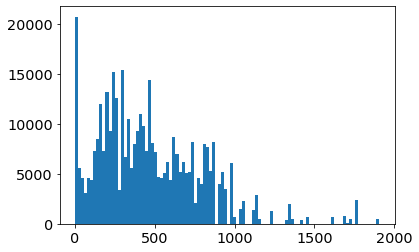

22416 0.056994515650862825


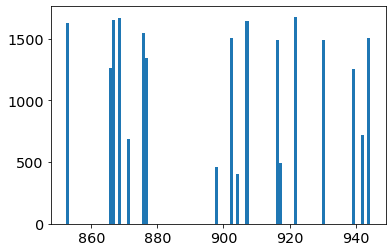

898.3029363306823
902.4139404296875


In [8]:
plt.hist(zbest['EFFTIME_DARK'], 100)
plt.show()

mask = (zbest['EFFTIME_DARK'] > 850) & (zbest['EFFTIME_DARK'] < 950)
print(np.sum(mask), np.sum(mask)/len(mask))

zbest = zbest[mask]

plt.hist(zbest['EFFTIME_DARK'], 100)
plt.show()

print(np.mean(zbest['EFFTIME_DARK']))
print(np.median(zbest['EFFTIME_DARK']))

In [9]:
gmag = zbest['gmag']
rmag = zbest['rmag']
zmag = zbest['zmag']
w1mag = zbest['w1mag']
w2mag = zbest['w2mag']
rfibermag = zbest['rfibermag']
zfibermag = zbest['zfibermag']
gaia_g = zbest['GAIA_PHOT_G_MEAN_MAG']

mask_north = zbest['PHOTSYS']=='N'
mask_south = zbest['PHOTSYS']=='S'

In [10]:
# Previous baseline (600/sqdeg) IR selection without the high-z extension (zfiber<21.5)
# Same as LRG_IR in v1.3

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - w1mag > (w1mag - 17.27) * 1.8 # sliding IR cut
lrg_mask &= rmag - w1mag > (w1mag - 16.37) * 1.  # low-z sliding IR cut

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg0_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - w1mag > (w1mag - 17.23) * 1.8 # sliding IR cut
lrg_mask &= rmag - w1mag > (w1mag - 16.33) * 1.  # low-z sliding IR cut

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.23)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg0_north = lrg_mask.copy()

lrg0 = lrg0_south | lrg0_north
print(np.sum(lrg0))

6340


In [11]:
# zfiber & sliding cut extension; 800 targets/sq.deg.

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.7)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.26) * 1.8 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.36) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.29
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag - rmag > 1.3) & ( (gmag - rmag) > -1.55 * (rmag - w1mag) + 3.13)
mask_lowz |= (rmag - w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g < 18)
lrg_mask &= (~mask_bright)

# lrg_mask &= (zfibertotmag>17.5)

lrg_sv3_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.72)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.24) * 1.83 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.33) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.39
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag - rmag > 1.34) & ( (gmag - rmag) > -1.55 * (rmag - w1mag) + 3.23)
mask_lowz |= (rmag - w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g < 18)
lrg_mask &= (~mask_bright)

# lrg_mask &= (zfibertotmag>17.5)

lrg_sv3_north = lrg_mask.copy()

lrg_sv3 = lrg_sv3_south | lrg_sv3_north
print(np.sum(lrg_sv3))

# zfiber & sliding cut extension; 600 targets/sq.deg.

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.7)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.07) * 1.8 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.17) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.39
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag - rmag > 1.3) & ( (gmag - rmag) > -1.55 * (rmag - w1mag) + 3.13)
mask_lowz |= (rmag - w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g < 18)
lrg_mask &= (~mask_bright)

# lrg_mask &= (zfibertotmag>17.5)

lrg_sv3_lowdens_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.72)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.05) * 1.83 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.14) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.49
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag - rmag > 1.34) & ( (gmag - rmag) > -1.55 * (rmag - w1mag) + 3.23)
mask_lowz |= (rmag - w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g < 18)
lrg_mask &= (~mask_bright)

# lrg_mask &= (zfibertotmag>17.5)

lrg_sv3_lowdens_north = lrg_mask.copy()

lrg_sv3_lowdens = lrg_sv3_lowdens_south | lrg_sv3_lowdens_north
print(np.sum(lrg_sv3_lowdens))

8240
6150


----------

In [12]:
# Not repeatable
zdiff_threshold = 0.0033
mask_fail = np.abs((zbest['Z'] - zbest['Z_deep'])/(1 + zbest['Z_deep'])) > zdiff_threshold
print(np.sum(mask_fail), np.sum(mask_fail)/len(mask_fail))
# Also include objects with ZWARN!=0 in the deep coadds
mask_zwarn = (zbest['ZWARN_deep']==0)
mask_fail |= (~mask_zwarn)
print(np.sum(mask_fail), np.sum(mask_fail)/len(mask_fail))

2058 0.09180942184154176
2075 0.09256780870806566


In [13]:
print('Overall failure rates:')
print('Previous IR sample: {:.1f}% ({}/{})'.format(np.sum(lrg0 & mask_fail)/np.sum(lrg0)*100, np.sum(lrg0 & mask_fail), np.sum(lrg0)))
print('SV3: {:.1f}% ({}/{})'.format(np.sum(lrg_sv3 & mask_fail)/np.sum(lrg_sv3)*100, np.sum(lrg_sv3 & mask_fail), np.sum(lrg_sv3)))
print('SV3 subsample:  {:.1f}% ({}/{})'.format(np.sum(lrg_sv3_lowdens & mask_fail)/np.sum(lrg_sv3_lowdens)*100, np.sum(lrg_sv3_lowdens & mask_fail), np.sum(lrg_sv3_lowdens)))

Overall failure rates:
Previous IR sample: 2.7% (171/6340)
SV3: 4.1% (339/8240)
SV3 subsample:  4.2% (257/6150)


In [14]:
# ZWARN cut on single exposures
mask_quality = zbest['ZWARN']==0

print('Fraction removed:')
print('Previous IR sample: {:.1f}%'.format(np.sum((~mask_quality) & lrg0)/np.sum(lrg0)*100))
print('SV3:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_sv3)/np.sum(lrg_sv3)*100))
print('SV3 subsample:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_sv3_lowdens)/np.sum(lrg_sv3_lowdens)*100))
print()

print('Overall failure rates:')
print('Previous IR sample: {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg0 & mask_fail)/np.sum(mask_quality & lrg0)*100, np.sum(mask_quality & lrg0 & mask_fail), np.sum(mask_quality & lrg0)))
print('SV3:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_sv3 & mask_fail)/np.sum(mask_quality & lrg_sv3)*100, np.sum(mask_quality & lrg_sv3 & mask_fail), np.sum(mask_quality & lrg_sv3)))
print('SV3 subsample:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_sv3_lowdens & mask_fail)/np.sum(mask_quality & lrg_sv3_lowdens)*100, np.sum(mask_quality & lrg_sv3_lowdens & mask_fail), np.sum(mask_quality & lrg_sv3_lowdens)))
print()

print('Failure rates of removed subset:')
print('Previous IR sample: {:.1f}% ({}/{})'.format(np.sum((~mask_quality) & lrg0 & mask_fail)/np.sum((~mask_quality) & lrg0)*100, np.sum((~mask_quality) & lrg0 & mask_fail), np.sum((~mask_quality) & lrg0)))
print('SV3:  {:.1f}% ({}/{})'.format(np.sum((~mask_quality) & lrg_sv3 & mask_fail)/np.sum((~mask_quality) & lrg_sv3)*100, np.sum((~mask_quality) & lrg_sv3 & mask_fail), np.sum((~mask_quality) & lrg_sv3)))
print('SV3 subsample:  {:.1f}% ({}/{})'.format(np.sum((~mask_quality) & lrg_sv3_lowdens & mask_fail)/np.sum((~mask_quality) & lrg_sv3_lowdens)*100, np.sum((~mask_quality) & lrg_sv3_lowdens & mask_fail), np.sum((~mask_quality) & lrg_sv3_lowdens)))

Fraction removed:
Previous IR sample: 1.6%
SV3:  3.4%
SV3 subsample:  3.5%

Overall failure rates:
Previous IR sample: 1.5% (96/6238)
SV3:  2.0% (161/7961)
SV3 subsample:  2.0% (119/5933)

Failure rates of removed subset:
Previous IR sample: 73.5% (75/102)
SV3:  63.8% (178/279)
SV3 subsample:  63.6% (138/217)


In [15]:
# ZWARN and redshift cuts on single exposures
mask_quality = zbest['ZWARN']==0
mask_quality &= zbest['Z']<1.4

print('Fraction removed:')
print('Previous IR sample: {:.1f}%'.format(np.sum((~mask_quality) & lrg0)/np.sum(lrg0)*100))
print('SV3:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_sv3)/np.sum(lrg_sv3)*100))
print('SV3 subsample:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_sv3_lowdens)/np.sum(lrg_sv3_lowdens)*100))
print()

print('Overall failure rates:')
print('Previous IR sample: {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg0 & mask_fail)/np.sum(mask_quality & lrg0)*100, np.sum(mask_quality & lrg0 & mask_fail), np.sum(mask_quality & lrg0)))
print('SV3:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_sv3 & mask_fail)/np.sum(mask_quality & lrg_sv3)*100, np.sum(mask_quality & lrg_sv3 & mask_fail), np.sum(mask_quality & lrg_sv3)))
print('SV3 subsample:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_sv3_lowdens & mask_fail)/np.sum(mask_quality & lrg_sv3_lowdens)*100, np.sum(mask_quality & lrg_sv3_lowdens & mask_fail), np.sum(mask_quality & lrg_sv3_lowdens)))
print()

print('Failure rates of removed subset:')
print('Previous IR sample: {:.1f}% ({}/{})'.format(np.sum((~mask_quality) & lrg0 & mask_fail)/np.sum((~mask_quality) & lrg0)*100, np.sum((~mask_quality) & lrg0 & mask_fail), np.sum((~mask_quality) & lrg0)))
print('SV3:  {:.1f}% ({}/{})'.format(np.sum((~mask_quality) & lrg_sv3 & mask_fail)/np.sum((~mask_quality) & lrg_sv3)*100, np.sum((~mask_quality) & lrg_sv3 & mask_fail), np.sum((~mask_quality) & lrg_sv3)))
print('SV3 subsample:  {:.1f}% ({}/{})'.format(np.sum((~mask_quality) & lrg_sv3_lowdens & mask_fail)/np.sum((~mask_quality) & lrg_sv3_lowdens)*100, np.sum((~mask_quality) & lrg_sv3_lowdens & mask_fail), np.sum((~mask_quality) & lrg_sv3_lowdens)))

Fraction removed:
Previous IR sample: 2.0%
SV3:  3.9%
SV3 subsample:  4.2%

Overall failure rates:
Previous IR sample: 1.3% (80/6213)
SV3:  1.7% (133/7918)
SV3 subsample:  1.6% (93/5893)

Failure rates of removed subset:
Previous IR sample: 71.7% (91/127)
SV3:  64.0% (206/322)
SV3 subsample:  63.8% (164/257)


In [16]:
# ZWARN, redshift, and DELTACHI2 cuts on single exposures

mask_quality = zbest['DELTACHI2']>15
mask_quality &= zbest['Z']<1.4
mask_quality &= zbest['ZWARN']==0

print('Fraction removed:')
print('Previous IR sample: {:.1f}%'.format(np.sum((~mask_quality) & lrg0)/np.sum(lrg0)*100))
print('SV3:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_sv3)/np.sum(lrg_sv3)*100))
print('SV3 subsample:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_sv3_lowdens)/np.sum(lrg_sv3_lowdens)*100))
print()

print('Overall failure rates:')
print('Previous IR sample: {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg0 & mask_fail)/np.sum(mask_quality & lrg0)*100, np.sum(mask_quality & lrg0 & mask_fail), np.sum(mask_quality & lrg0)))
print('SV3:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_sv3 & mask_fail)/np.sum(mask_quality & lrg_sv3)*100, np.sum(mask_quality & lrg_sv3 & mask_fail), np.sum(mask_quality & lrg_sv3)))
print('SV3 subsample:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_sv3_lowdens & mask_fail)/np.sum(mask_quality & lrg_sv3_lowdens)*100, np.sum(mask_quality & lrg_sv3_lowdens & mask_fail), np.sum(mask_quality & lrg_sv3_lowdens)))
print()

print('Failure rates of removed subset:')
print('Previous IR sample: {:.1f}% ({}/{})'.format(np.sum((~mask_quality) & lrg0 & mask_fail)/np.sum((~mask_quality) & lrg0)*100, np.sum((~mask_quality) & lrg0 & mask_fail), np.sum((~mask_quality) & lrg0)))
print('SV3:  {:.1f}% ({}/{})'.format(np.sum((~mask_quality) & lrg_sv3 & mask_fail)/np.sum((~mask_quality) & lrg_sv3)*100, np.sum((~mask_quality) & lrg_sv3 & mask_fail), np.sum((~mask_quality) & lrg_sv3)))
print('SV3 subsample:  {:.1f}% ({}/{})'.format(np.sum((~mask_quality) & lrg_sv3_lowdens & mask_fail)/np.sum((~mask_quality) & lrg_sv3_lowdens)*100, np.sum((~mask_quality) & lrg_sv3_lowdens & mask_fail), np.sum((~mask_quality) & lrg_sv3_lowdens)))

Fraction removed:
Previous IR sample: 2.8%
SV3:  5.8%
SV3 subsample:  6.3%

Overall failure rates:
Previous IR sample: 1.0% (59/6161)
SV3:  1.2% (94/7759)
SV3 subsample:  1.1% (66/5764)

Failure rates of removed subset:
Previous IR sample: 62.6% (112/179)
SV3:  50.9% (245/481)
SV3 subsample:  49.5% (191/386)


In [17]:
# MEDIUM and WISE masks
maskbits = [8, 11]
mask_quality = np.ones(len(zbest), dtype=bool)
for bit in maskbits:
    mask_quality &= (zbest['MASKBITS'] & 2**bit)==0

print('Fraction removed:')
print('Previous IR sample: {:.1f}%'.format(np.sum((~mask_quality) & lrg0)/np.sum(lrg0)*100))
print('SV3:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_sv3)/np.sum(lrg_sv3)*100))
print('SV3 subsample:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_sv3_lowdens)/np.sum(lrg_sv3_lowdens)*100))
print()

print('Overall failure rates:')
print('Previous IR sample: {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg0 & mask_fail)/np.sum(mask_quality & lrg0)*100, np.sum(mask_quality & lrg0 & mask_fail), np.sum(mask_quality & lrg0)))
print('SV3:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_sv3 & mask_fail)/np.sum(mask_quality & lrg_sv3)*100, np.sum(mask_quality & lrg_sv3 & mask_fail), np.sum(mask_quality & lrg_sv3)))
print('SV3 subsample:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_sv3_lowdens & mask_fail)/np.sum(mask_quality & lrg_sv3_lowdens)*100, np.sum(mask_quality & lrg_sv3_lowdens & mask_fail), np.sum(mask_quality & lrg_sv3_lowdens)))
print()

print('Failure rates of removed subset:')
print('Previous IR sample: {:.1f}% ({}/{})'.format(np.sum((~mask_quality) & lrg0 & mask_fail)/np.sum((~mask_quality) & lrg0)*100, np.sum((~mask_quality) & lrg0 & mask_fail), np.sum((~mask_quality) & lrg0)))
print('SV3:  {:.1f}% ({}/{})'.format(np.sum((~mask_quality) & lrg_sv3 & mask_fail)/np.sum((~mask_quality) & lrg_sv3)*100, np.sum((~mask_quality) & lrg_sv3 & mask_fail), np.sum((~mask_quality) & lrg_sv3)))
print('SV3 subsample:  {:.1f}% ({}/{})'.format(np.sum((~mask_quality) & lrg_sv3_lowdens & mask_fail)/np.sum((~mask_quality) & lrg_sv3_lowdens)*100, np.sum((~mask_quality) & lrg_sv3_lowdens & mask_fail), np.sum((~mask_quality) & lrg_sv3_lowdens)))

Fraction removed:
Previous IR sample: 6.9%
SV3:  6.5%
SV3 subsample:  6.5%

Overall failure rates:
Previous IR sample: 2.7% (161/5901)
SV3:  4.2% (323/7703)
SV3 subsample:  4.2% (243/5750)

Failure rates of removed subset:
Previous IR sample: 2.3% (10/439)
SV3:  3.0% (16/537)
SV3 subsample:  3.5% (14/400)


-------

[17.4 17.5 17.6 17.7 17.8 17.9 18.  18.1 18.2 18.3 18.4 18.5 18.6 18.7
 18.8 18.9 19.  19.1 19.2 19.3 19.4 19.5 19.6 19.7 19.8 19.9 20.  20.1
 20.2 20.3 20.4 20.5 20.6 20.7 20.8 20.9 21.  21.1 21.2 21.3 21.4 21.5
 21.6 21.7 21.8 21.9 22. ]


<ipython-input-18-f339a9c305de>:7: RuntimeWarning: invalid value encountered in true_divide
  n, p_lrg_sv3 = n_lrg_sv3, n_lrg_sv3_fail/n_lrg_sv3
<ipython-input-18-f339a9c305de>:8: RuntimeWarning: divide by zero encountered in true_divide
  p1 = np.maximum(p_lrg_sv3, 1/n)  # error floor
<ipython-input-18-f339a9c305de>:13: RuntimeWarning: invalid value encountered in true_divide
  n, p_lrg_sv3_lowdens = n_lrg_sv3_lowdens, n_lrg_sv3_lowdens_fail/n_lrg_sv3_lowdens
<ipython-input-18-f339a9c305de>:14: RuntimeWarning: divide by zero encountered in true_divide
  p1 = np.maximum(p_lrg_sv3_lowdens, 1/n)  # error floor


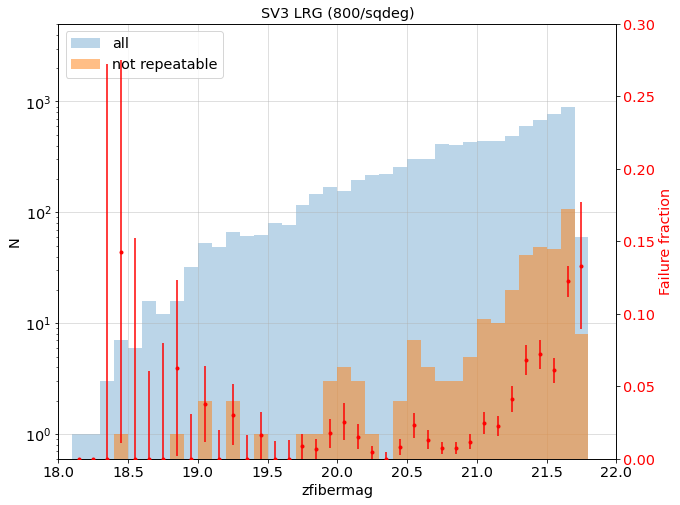

In [18]:
bins = np.linspace(17.4, 22., 47)
print(bins)
bin_centers = (bins[1:]+bins[:-1])/2

n_lrg_sv3, _ = np.histogram(zbest['zfibermag'][lrg_sv3], bins=bins)
n_lrg_sv3_fail, _ = np.histogram(zbest['zfibermag'][lrg_sv3 & mask_fail], bins=bins)
n, p_lrg_sv3 = n_lrg_sv3, n_lrg_sv3_fail/n_lrg_sv3
p1 = np.maximum(p_lrg_sv3, 1/n)  # error floor
errors_sv3 = np.clip(np.sqrt(n * p_lrg_sv3 * (1-p_lrg_sv3))/n, np.sqrt(n * p1 * (1-p1))/n, 1)

n_lrg_sv3_lowdens, _ = np.histogram(zbest['zfibermag'][lrg_sv3_lowdens], bins=bins)
n_lrg_sv3_lowdens_fail, _ = np.histogram(zbest['zfibermag'][lrg_sv3_lowdens & mask_fail], bins=bins)
n, p_lrg_sv3_lowdens = n_lrg_sv3_lowdens, n_lrg_sv3_lowdens_fail/n_lrg_sv3_lowdens
p1 = np.maximum(p_lrg_sv3_lowdens, 1/n)  # error floor
errors_sv3_lowdens = np.clip(np.sqrt(n * p_lrg_sv3_lowdens * (1-p_lrg_sv3_lowdens))/n, np.sqrt(n * p1 * (1-p1))/n, 1)

fig, ax1 = plt.subplots(figsize=(10, 8))
ax1.hist(zbest['zfibermag'][lrg_sv3], bins=bins, alpha=0.3, label='all', zorder=1, log=True)
ax1.hist(zbest['zfibermag'][mask_fail & lrg_sv3], bins=bins, alpha=0.5, label='not repeatable', zorder=2)
ax1.set_xlabel('zfibermag')
ax1.set_ylabel('N')
ax1.set_title('SV3 LRG (800/sqdeg)')
ax1.legend(loc='upper left')
ax1.grid(alpha=0.5)
ax1.set_ylim(0.6, 5e3)
ax2 = ax1.twinx()
color = 'r'
ax2.errorbar(bin_centers, p_lrg_sv3, yerr=(np.clip(errors_sv3, None, p_lrg_sv3), errors_sv3),
             fmt='.', label='SV3 LRG (800/sqdeg)', zorder=3, color=color)
ax2.set_xlabel('zfibermag', color=color)
ax2.set_ylabel('Failure fraction', color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_xlim(18, 22)
ax2.set_ylim(0, 0.3)
plt.show()

[19.  19.1 19.2 19.3 19.4 19.5 19.6 19.7 19.8 19.9 20.  20.1 20.2 20.3
 20.4 20.5 20.6 20.7 20.8 20.9 21.  21.1 21.2 21.3 21.4 21.5 21.6 21.7
 21.8 21.9 22.  22.1 22.2 22.3 22.4 22.5 22.6 22.7 22.8 22.9 23.  23.1
 23.2 23.3 23.4 23.5 23.6 23.7 23.8 23.9 24.  24.1 24.2 24.3 24.4 24.5]


<ipython-input-19-51e4381488d4>:7: RuntimeWarning: invalid value encountered in true_divide
  n, p_lrg_sv3 = n_lrg_sv3, n_lrg_sv3_fail/n_lrg_sv3
<ipython-input-19-51e4381488d4>:8: RuntimeWarning: divide by zero encountered in true_divide
  p1 = np.maximum(p_lrg_sv3, 1/n)  # error floor
<ipython-input-19-51e4381488d4>:13: RuntimeWarning: invalid value encountered in true_divide
  n, p_lrg_sv3_lowdens = n_lrg_sv3_lowdens, n_lrg_sv3_lowdens_fail/n_lrg_sv3_lowdens
<ipython-input-19-51e4381488d4>:14: RuntimeWarning: divide by zero encountered in true_divide
  p1 = np.maximum(p_lrg_sv3_lowdens, 1/n)  # error floor


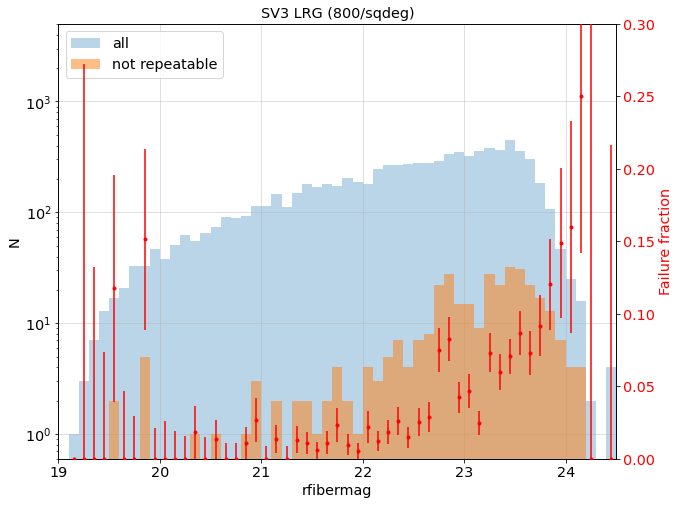

In [19]:
bins = np.linspace(19, 24.5, 56)
print(bins)
bin_centers = (bins[1:]+bins[:-1])/2

n_lrg_sv3, _ = np.histogram(zbest['rfibermag'][lrg_sv3], bins=bins)
n_lrg_sv3_fail, _ = np.histogram(zbest['rfibermag'][lrg_sv3 & mask_fail], bins=bins)
n, p_lrg_sv3 = n_lrg_sv3, n_lrg_sv3_fail/n_lrg_sv3
p1 = np.maximum(p_lrg_sv3, 1/n)  # error floor
errors_sv3 = np.clip(np.sqrt(n * p_lrg_sv3 * (1-p_lrg_sv3))/n, np.sqrt(n * p1 * (1-p1))/n, 1)

n_lrg_sv3_lowdens, _ = np.histogram(zbest['rfibermag'][lrg_sv3_lowdens], bins=bins)
n_lrg_sv3_lowdens_fail, _ = np.histogram(zbest['rfibermag'][lrg_sv3_lowdens & mask_fail], bins=bins)
n, p_lrg_sv3_lowdens = n_lrg_sv3_lowdens, n_lrg_sv3_lowdens_fail/n_lrg_sv3_lowdens
p1 = np.maximum(p_lrg_sv3_lowdens, 1/n)  # error floor
errors_sv3_lowdens = np.clip(np.sqrt(n * p_lrg_sv3_lowdens * (1-p_lrg_sv3_lowdens))/n, np.sqrt(n * p1 * (1-p1))/n, 1)

fig, ax1 = plt.subplots(figsize=(10, 8))
ax1.hist(zbest['rfibermag'][lrg_sv3], bins=bins, alpha=0.3, label='all', zorder=1, log=True)
ax1.hist(zbest['rfibermag'][mask_fail & lrg_sv3], bins=bins, alpha=0.5, label='not repeatable', zorder=2)
ax1.set_xlabel('rfibermag')
ax1.set_ylabel('N')
ax1.set_title('SV3 LRG (800/sqdeg)')
ax1.legend(loc='upper left')
ax1.grid(alpha=0.5)
ax1.set_ylim(0.6, 5e3)
ax2 = ax1.twinx()
color = 'r'
ax2.errorbar(bin_centers, p_lrg_sv3, yerr=(np.clip(errors_sv3, None, p_lrg_sv3), errors_sv3),
             fmt='.', label='SV3 LRG (800/sqdeg)', zorder=3, color=color)
ax2.set_xlabel('rfibermag', color=color)
ax2.set_ylabel('Failure fraction', color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_xlim(19, 24.5)
ax2.set_ylim(0, 0.3)
plt.show()

----------
# Apply quality cuts

[17.4 17.5 17.6 17.7 17.8 17.9 18.  18.1 18.2 18.3 18.4 18.5 18.6 18.7
 18.8 18.9 19.  19.1 19.2 19.3 19.4 19.5 19.6 19.7 19.8 19.9 20.  20.1
 20.2 20.3 20.4 20.5 20.6 20.7 20.8 20.9 21.  21.1 21.2 21.3 21.4 21.5
 21.6 21.7 21.8 21.9 22. ]


<ipython-input-20-5d7c55970a27>:11: RuntimeWarning: invalid value encountered in true_divide
  n, p_lrg_sv3 = n_lrg_sv3, n_lrg_sv3_fail/n_lrg_sv3
<ipython-input-20-5d7c55970a27>:12: RuntimeWarning: divide by zero encountered in true_divide
  p1 = np.maximum(p_lrg_sv3, 1/n)  # error floor
<ipython-input-20-5d7c55970a27>:17: RuntimeWarning: invalid value encountered in true_divide
  n, p_lrg_sv3_lowdens = n_lrg_sv3_lowdens, n_lrg_sv3_lowdens_fail/n_lrg_sv3_lowdens
<ipython-input-20-5d7c55970a27>:18: RuntimeWarning: divide by zero encountered in true_divide
  p1 = np.maximum(p_lrg_sv3_lowdens, 1/n)  # error floor


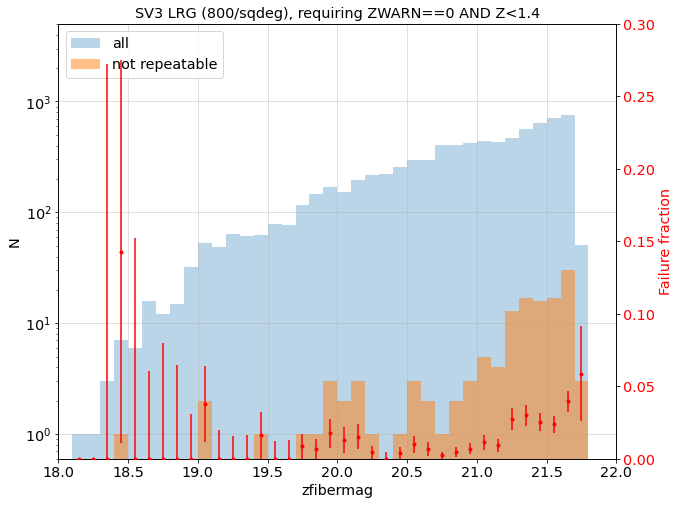

In [20]:
# ZWARN and redshift cuts on single exposures
mask_quality = zbest['ZWARN']==0
mask_quality &= zbest['Z']<1.4

bins = np.linspace(17.4, 22., 47)
print(bins)
bin_centers = (bins[1:]+bins[:-1])/2

n_lrg_sv3, _ = np.histogram(zbest['zfibermag'][lrg_sv3 & mask_quality], bins=bins)
n_lrg_sv3_fail, _ = np.histogram(zbest['zfibermag'][lrg_sv3 & mask_quality & mask_fail], bins=bins)
n, p_lrg_sv3 = n_lrg_sv3, n_lrg_sv3_fail/n_lrg_sv3
p1 = np.maximum(p_lrg_sv3, 1/n)  # error floor
errors_sv3 = np.clip(np.sqrt(n * p_lrg_sv3 * (1-p_lrg_sv3))/n, np.sqrt(n * p1 * (1-p1))/n, 1)

n_lrg_sv3_lowdens, _ = np.histogram(zbest['zfibermag'][lrg_sv3_lowdens], bins=bins)
n_lrg_sv3_lowdens_fail, _ = np.histogram(zbest['zfibermag'][lrg_sv3_lowdens & mask_fail], bins=bins)
n, p_lrg_sv3_lowdens = n_lrg_sv3_lowdens, n_lrg_sv3_lowdens_fail/n_lrg_sv3_lowdens
p1 = np.maximum(p_lrg_sv3_lowdens, 1/n)  # error floor
errors_sv3_lowdens = np.clip(np.sqrt(n * p_lrg_sv3_lowdens * (1-p_lrg_sv3_lowdens))/n, np.sqrt(n * p1 * (1-p1))/n, 1)

fig, ax1 = plt.subplots(figsize=(10, 8))
ax1.hist(zbest['zfibermag'][lrg_sv3 & mask_quality], bins=bins, alpha=0.3, label='all', zorder=1, log=True)
ax1.hist(zbest['zfibermag'][mask_fail & lrg_sv3 & mask_quality], bins=bins, alpha=0.5, label='not repeatable', zorder=2)
ax1.set_xlabel('zfibermag')
ax1.set_ylabel('N')
ax1.set_title('SV3 LRG (800/sqdeg), requiring ZWARN==0 AND Z<1.4')
ax1.legend(loc='upper left')
ax1.grid(alpha=0.5)
ax1.set_ylim(0.6, 5e3)
ax2 = ax1.twinx()
color = 'r'
ax2.errorbar(bin_centers, p_lrg_sv3, yerr=(np.clip(errors_sv3, None, p_lrg_sv3), errors_sv3),
             fmt='.', label='SV3 LRG (800/sqdeg)', zorder=3, color=color)
ax2.set_xlabel('zfibermag', color=color)
ax2.set_ylabel('Failure fraction', color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_xlim(18, 22)
ax2.set_ylim(0, 0.3)
plt.show()

[17.4 17.5 17.6 17.7 17.8 17.9 18.  18.1 18.2 18.3 18.4 18.5 18.6 18.7
 18.8 18.9 19.  19.1 19.2 19.3 19.4 19.5 19.6 19.7 19.8 19.9 20.  20.1
 20.2 20.3 20.4 20.5 20.6 20.7 20.8 20.9 21.  21.1 21.2 21.3 21.4 21.5
 21.6 21.7 21.8 21.9 22. ]


<ipython-input-21-597c8e103137>:12: RuntimeWarning: invalid value encountered in true_divide
  n, p_lrg_sv3 = n_lrg_sv3, n_lrg_sv3_fail/n_lrg_sv3
<ipython-input-21-597c8e103137>:13: RuntimeWarning: divide by zero encountered in true_divide
  p1 = np.maximum(p_lrg_sv3, 1/n)  # error floor
<ipython-input-21-597c8e103137>:18: RuntimeWarning: invalid value encountered in true_divide
  n, p_lrg_sv3_lowdens = n_lrg_sv3_lowdens, n_lrg_sv3_lowdens_fail/n_lrg_sv3_lowdens
<ipython-input-21-597c8e103137>:19: RuntimeWarning: divide by zero encountered in true_divide
  p1 = np.maximum(p_lrg_sv3_lowdens, 1/n)  # error floor


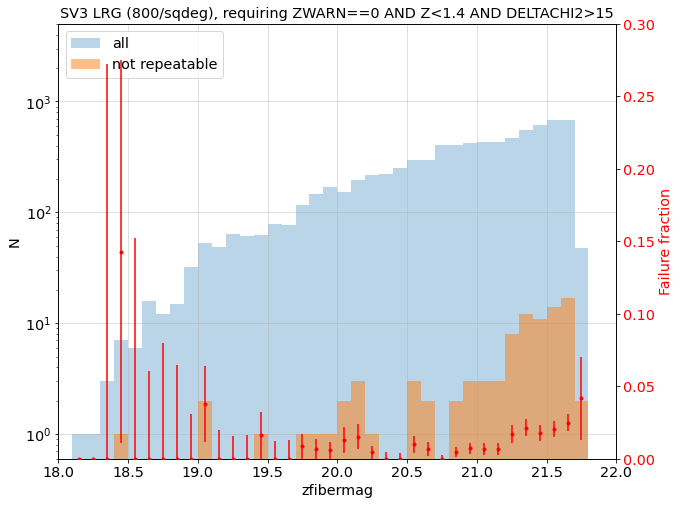

In [21]:
# ZWARN and redshift cuts on single exposures
mask_quality = zbest['DELTACHI2']>15
mask_quality &= zbest['Z']<1.4
mask_quality &= zbest['ZWARN']==0

bins = np.linspace(17.4, 22., 47)
print(bins)
bin_centers = (bins[1:]+bins[:-1])/2

n_lrg_sv3, _ = np.histogram(zbest['zfibermag'][lrg_sv3 & mask_quality], bins=bins)
n_lrg_sv3_fail, _ = np.histogram(zbest['zfibermag'][lrg_sv3 & mask_quality & mask_fail], bins=bins)
n, p_lrg_sv3 = n_lrg_sv3, n_lrg_sv3_fail/n_lrg_sv3
p1 = np.maximum(p_lrg_sv3, 1/n)  # error floor
errors_sv3 = np.clip(np.sqrt(n * p_lrg_sv3 * (1-p_lrg_sv3))/n, np.sqrt(n * p1 * (1-p1))/n, 1)

n_lrg_sv3_lowdens, _ = np.histogram(zbest['zfibermag'][lrg_sv3_lowdens], bins=bins)
n_lrg_sv3_lowdens_fail, _ = np.histogram(zbest['zfibermag'][lrg_sv3_lowdens & mask_fail], bins=bins)
n, p_lrg_sv3_lowdens = n_lrg_sv3_lowdens, n_lrg_sv3_lowdens_fail/n_lrg_sv3_lowdens
p1 = np.maximum(p_lrg_sv3_lowdens, 1/n)  # error floor
errors_sv3_lowdens = np.clip(np.sqrt(n * p_lrg_sv3_lowdens * (1-p_lrg_sv3_lowdens))/n, np.sqrt(n * p1 * (1-p1))/n, 1)

fig, ax1 = plt.subplots(figsize=(10, 8))
ax1.hist(zbest['zfibermag'][lrg_sv3 & mask_quality], bins=bins, alpha=0.3, label='all', zorder=1, log=True)
ax1.hist(zbest['zfibermag'][mask_fail & lrg_sv3 & mask_quality], bins=bins, alpha=0.5, label='not repeatable', zorder=2)
ax1.set_xlabel('zfibermag')
ax1.set_ylabel('N')
ax1.set_title('SV3 LRG (800/sqdeg), requiring ZWARN==0 AND Z<1.4 AND DELTACHI2>15')
ax1.legend(loc='upper left')
ax1.grid(alpha=0.5)
ax1.set_ylim(0.6, 5e3)
ax2 = ax1.twinx()
color = 'r'
ax2.errorbar(bin_centers, p_lrg_sv3, yerr=(np.clip(errors_sv3, None, p_lrg_sv3), errors_sv3),
             fmt='.', label='SV3 LRG (800/sqdeg)', zorder=3, color=color)
ax2.set_xlabel('zfibermag', color=color)
ax2.set_ylabel('Failure fraction', color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_xlim(18, 22)
ax2.set_ylim(0, 0.3)
plt.show()

----------
# Failure rates per exposure

In [32]:
t = Table()
t['EXPID'], t['n_all'] = np.unique(zbest['EXPID'][lrg_sv3], return_counts=True)
t1 = Table()
t1['EXPID'], t1['n_fail'] = np.unique(zbest['EXPID'][lrg_sv3 & mask_fail], return_counts=True)
t = join(t, t1, keys='EXPID')
t['fail_frac (%)'] = t['n_fail']/t['n_all']*100
t['fail_frac (%)'].format = '%.1f'
t.sort('fail_frac (%)')
t

EXPID,n_all,n_fail,fail_frac (%)
int64,int64,int64,float64
81531,287,1,0.3
80680,200,4,2.0
79886,187,5,2.7
80690,262,8,3.1
68339,555,17,3.1
74620,559,18,3.2
74621,561,19,3.4
68337,553,19,3.4
68879,451,16,3.5


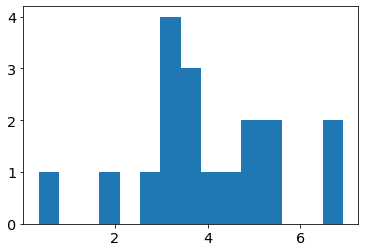

In [36]:
plt.hist(t['fail_frac (%)'], 15);